# 베이스라인 모델 비교 (`01_Baseline_Models`)

25일 시점 재학생(`model_df_clean`, 27,654행)을 대상으로 **25일 이후 중도 이탈**을 예측하는
베이스라인 모델을 비교하고 챔피언 모델을 선정한다. `work_process/reports/04_next_steps.md`
P4에 해당한다.

진행 순서는 다음과 같다.

1. 데이터·피처 명세 로드와 계약 검증
2. `2014J` holdout 분리
3. 교차검증 분할(`StratifiedGroupKFold`) 고정
4. 모델별 `Pipeline` 정의 — Dummy / Logistic / RandomForest / XGBoost
5. 동일 루프로 튜닝·비교 (주 지표 PR-AUC)
6. OOF 예측으로 Recall·Precision·F1·ROC-AUC·혼동행렬 비교
7. 챔피언 선정과 임계값 선택
8. 챔피언만 `2014J` holdout 평가
9. 결과 저장

선행 문서:

- `work_process/decisions/preprocessing/0912_03_collinearity_final_features.md` (최종 피처, 9절 모델별 전처리, 10절 검증 분할)
- `work_process/decisions/preprocessing/0912_01_missing_value_policy.md` (결측 전략)
- `work_process/decisions/modeling/0902_01_landmark_n25_final.md` (N=25 확정)

## 1. 환경 설정 및 데이터 로드

In [1]:
import json
import platform
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
import xgboost
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    f1_score,
    fbeta_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedGroupKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from xgboost import XGBClassifier

# 그래프 한글 라벨 (기존 노트북과 동일한 설정)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 60)

RANDOM_STATE = 42


def show(frame, formats=None):
    # jinja2 없이 열별 서식을 적용해 표시한다
    view = frame.copy()
    for col, f in (formats or {}).items():
        if col in view.columns:
            view[col] = view[col].map(lambda v, f=f: f.format(v) if pd.notna(v) else '')
    display(view)


PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'CSV_files').exists():
    PROJECT_ROOT = (PROJECT_ROOT / '../..').resolve()

DATA_DIR = PROJECT_ROOT / 'CSV_files' / '통합 버전'
SPEC_PATH = DATA_DIR / 'feature_spec_n25.json'
CLEAN_PATH = DATA_DIR / 'model_df_clean_n25.csv'
OUTPUT_DIR = PROJECT_ROOT / 'CSV_files' / '모델링'

with open(SPEC_PATH, encoding='utf-8') as f:
    spec = json.load(f)

model_df_clean = pd.read_csv(CLEAN_PATH)

print('Python     :', platform.python_version())
print('pandas     :', pd.__version__)
print('scikit-learn:', sklearn.__version__)
print('xgboost    :', xgboost.__version__)
print()
print('데이터 shape:', model_df_clean.shape)

Python     : 3.14.5
pandas     : 3.0.3
scikit-learn: 1.9.0
xgboost    : 3.3.0

데이터 shape: (27654, 29)


### 1.1 피처 명세 적용과 데이터 계약 검증

피처 목록은 노트북에서 다시 정의하지 않고 **`feature_spec_n25.json`만 읽는다**(04 노트북이 정본
생성자). `presentation_period`는 명세의 파생 규칙대로 만든다.

검증 항목:

- 행 수·양성 수가 명세와 일치
- 그레인 `(id_student, code_module, code_presentation)` 유일
- 피처 목록에 누수·식별자·제외 컬럼이 없음
- NaN 보유 피처가 명세의 `nan_features`와 정확히 일치

In [2]:
TARGET = spec['target']
GROUP_COL = spec['group_col']
HOLDOUT_KEY = spec['holdout_key']
NUM_FEATURES = spec['numeric_features']
CAT_FEATURES = spec['categorical_features']
FEATURES = NUM_FEATURES + CAT_FEATURES
GRAIN = ['id_student', 'code_module', 'code_presentation']

df = model_df_clean.copy()
df['presentation_period'] = df['code_presentation'].str[-1]
df[TARGET] = df[TARGET].astype(int)

assert len(df) == spec['n_rows'], '행 수가 피처 명세와 다름'
assert df[TARGET].sum() == spec['n_positive'], '양성 수가 피처 명세와 다름'
assert not df.duplicated(GRAIN).any(), '그레인 키 중복'
assert len(FEATURES) == 19, '최종 피처는 19개여야 함'

forbidden = set(spec['excluded']) | {TARGET}
assert not forbidden & set(FEATURES), f'금지 컬럼 포함: {forbidden & set(FEATURES)}'

nan_cols = sorted(df[FEATURES].columns[df[FEATURES].isna().any()])
assert nan_cols == sorted(spec['nan_features']), f'NaN 보유 피처 불일치: {nan_cols}'
assert set(df['presentation_period'].unique()) == {'B', 'J'}

print(f'피처 {len(FEATURES)}개 (수치형 {len(NUM_FEATURES)} + 범주형 {len(CAT_FEATURES)})')
print(f'행 {len(df):,} / 양성 {df[TARGET].sum():,} ({df[TARGET].mean():.2%})')
print()
print('NaN 보유 피처:')
print(df[spec['nan_features']].isna().sum())

피처 19개 (수치형 11 + 범주형 8)
행 27,654 / 양성 5,246 (18.97%)

NaN 보유 피처:
avg_score_25           10016
avg_submit_delay_25    10010
dtype: int64


## 2. `2014J` holdout 분리

마지막 학기 `2014J`를 **최종 평가 전용**으로 떼어낸다. 이후 튜닝·모델 비교·임계값 선택은 모두
나머지 3개 학기(개발 세트)에서만 하고, holdout은 8절에서 챔피언 모델에 **한 번만** 쓴다.

In [3]:
HOLDOUT_TERM = '2014J'

is_holdout = df[HOLDOUT_KEY] == HOLDOUT_TERM
dev_df = df.loc[~is_holdout].reset_index(drop=True)
hold_df = df.loc[is_holdout].reset_index(drop=True)

X_dev, y_dev, groups_dev = dev_df[FEATURES], dev_df[TARGET], dev_df[GROUP_COL]
X_hold, y_hold = hold_df[FEATURES], hold_df[TARGET]

assert len(hold_df) == 9150, 'holdout 행 수가 결정 문서(9,150행)와 다름'
assert len(dev_df) + len(hold_df) == len(df)

split_summary = pd.DataFrame({
    '행 수': [len(dev_df), len(hold_df)],
    '양성 수': [y_dev.sum(), y_hold.sum()],
    '이탈률': [y_dev.mean(), y_hold.mean()],
    '학생 수': [dev_df[GROUP_COL].nunique(), hold_df[GROUP_COL].nunique()],
}, index=['개발(2013B·2013J·2014B)', 'holdout(2014J)'])
show(split_summary, {'이탈률': '{:.2%}', '행 수': '{:,}', '양성 수': '{:,}', '학생 수': '{:,}'})

print('개발 세트 학기 구성:', dev_df[HOLDOUT_KEY].value_counts().sort_index().to_dict())

overlap_students = set(dev_df[GROUP_COL]) & set(hold_df[GROUP_COL])
print(f'개발·holdout 양쪽에 모두 등장하는 학생: {len(overlap_students):,}명 '
      f'(holdout 행의 {hold_df[GROUP_COL].isin(overlap_students).mean():.2%})')

,행 수,양성 수,이탈률,학생 수
개발(2013B·2013J·2014B),"18,504","3,526",19.06%,"17,407"
holdout(2014J),"9,150","1,720",18.80%,"8,799"


개발 세트 학기 구성: {'2013B': 4274, '2013J': 7692, '2014B': 6538}
개발·holdout 양쪽에 모두 등장하는 학생: 1,259명 (holdout 행의 14.02%)


개발·holdout에 동시에 등장하는 학생은 **제거하지 않는다.** holdout은 "과거 학기로 학습해 다음
학기를 예측"하는 시간 분할이고, 실제 배포에서도 이전 학기 수강 이력이 있는 학생이 새 학기에
다시 등록한다. 입력 피처에는 학생 ID나 과거 결과가 없으므로(이력은 `num_of_prev_attempts`만)
이 겹침은 누수가 아니라 현실적인 조건이다.

## 3. 교차검증 분할 고정

`StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)`, `groups=id_student`.
분할 인덱스를 **한 번만 생성해 리스트로 고정**하고 모든 모델의 튜닝·OOF 예측에 그대로 넘긴다.
객체를 모델마다 새로 쓰면 fold 구성이 달라져 비교가 공정하지 않다.

In [4]:
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
CV_SPLITS = list(sgkf.split(X_dev, y_dev, groups=groups_dev))

fold_rows = []
covered = np.zeros(len(X_dev), dtype=int)
for i, (tr, va) in enumerate(CV_SPLITS):
    assert not set(groups_dev.iloc[tr]) & set(groups_dev.iloc[va]), f'fold {i}: 학생 중복'
    covered[va] += 1
    fold_rows.append({
        'fold': i,
        '학습 행': len(tr),
        '검증 행': len(va),
        '검증 이탈률': y_dev.iloc[va].mean(),
    })
assert (covered == 1).all(), '모든 개발 행이 정확히 한 번씩 검증에 쓰여야 함'

show(pd.DataFrame(fold_rows), {'검증 이탈률': '{:.2%}'})
print('fold 간 학생 중복 0건, 모든 행이 정확히 1회 검증됨')

,fold,학습 행,검증 행,검증 이탈률
0,0,14802,3702,19.04%
1,1,14802,3702,19.07%
2,2,14804,3700,19.05%
3,3,14804,3700,19.05%
4,4,14804,3700,19.05%


fold 간 학생 중복 0건, 모든 행이 정확히 1회 검증됨


## 4. 모델별 `Pipeline` 정의

결정 문서 9절 표를 그대로 구현한다. 전처리는 모두 `Pipeline` 안에 있어 **각 fold의 학습
부분에서만 `fit`** 된다.

| 처리 | Logistic | RandomForest | XGBoost |
|---|---|---|---|
| 수치형 결측 | `SimpleImputer(median, add_indicator=True)` | 동일 | 대치 안 함 (NaN 유지) |
| 수치형 스케일링 | `RobustScaler` | 없음 | 없음 |
| 범주형 | `OneHotEncoder(drop='first')` | `OneHotEncoder` | `OneHotEncoder` |
| 불균형 | `class_weight='balanced'` | `class_weight='balanced'` | `scale_pos_weight` |

**XGBoost 주의점**: XGBoost는 희소 행렬에서 *저장되지 않은 0*을 결측으로 취급한다. 원-핫
결과가 희소 행렬로 넘어가면 `code_module_AAA = 0`이나 `total_click_25 = 0`이 NaN처럼
학습되어 "NaN 방향을 스스로 학습"하게 한 전략이 오염된다. 그래서 XGBoost 전처리는
`sparse_output=False`, `sparse_threshold=0`으로 **밀집 행렬을 강제**한다.

`scale_pos_weight`는 개발 세트의 음성/양성 비율로 고정한다. fold마다 이탈률 차이가 0.5%p
안쪽이라 fold별 재계산과 사실상 차이가 없다.

In [5]:
def make_logistic_preprocessor():
    return ColumnTransformer([
        ('num', Pipeline([
            ('impute', SimpleImputer(strategy='median', add_indicator=True)),
            ('scale', RobustScaler()),
        ]), NUM_FEATURES),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), CAT_FEATURES),
    ])


def make_tree_preprocessor():
    return ColumnTransformer([
        ('num', SimpleImputer(strategy='median', add_indicator=True), NUM_FEATURES),
        ('cat', OneHotEncoder(handle_unknown='ignore'), CAT_FEATURES),
    ])


def make_xgb_preprocessor():
    return ColumnTransformer(
        [
            ('num', 'passthrough', NUM_FEATURES),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_FEATURES),
        ],
        sparse_threshold=0,
    )


SCALE_POS_WEIGHT = (y_dev == 0).sum() / (y_dev == 1).sum()
print(f'scale_pos_weight = {SCALE_POS_WEIGHT:.3f}')

MODEL_SPECS = [
    (
        'Dummy',
        Pipeline([('model', DummyClassifier(strategy='prior'))]),
        {},
    ),
    (
        'Logistic',
        Pipeline([
            ('prep', make_logistic_preprocessor()),
            ('model', LogisticRegression(class_weight='balanced', max_iter=5000)),
        ]),
        {'model__C': [0.01, 0.1, 1.0, 10.0, 100.0]},
    ),
    (
        'RandomForest',
        Pipeline([
            ('prep', make_tree_preprocessor()),
            ('model', RandomForestClassifier(
                n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=1,
            )),
        ]),
        {
            'model__max_depth': [None, 12],
            'model__min_samples_leaf': [10, 30, 60],
            'model__max_features': ['sqrt', 0.5, 0.8],
        },
    ),
    (
        'XGBoost',
        Pipeline([
            ('prep', make_xgb_preprocessor()),
            ('model', XGBClassifier(
                n_estimators=400,
                subsample=0.8,
                colsample_bytree=0.8,
                scale_pos_weight=SCALE_POS_WEIGHT,
                tree_method='hist',
                eval_metric='aucpr',
                random_state=RANDOM_STATE,
                n_jobs=1,
            )),
        ]),
        {
            'model__max_depth': [2, 3, 5],
            'model__learning_rate': [0.01, 0.03, 0.1],
            'model__min_child_weight': [1, 10, 30],
        },
    ),
]

# XGBoost 입력이 실제로 밀집 행렬이고 NaN이 살아 있는지 확인
_xgb_check = make_xgb_preprocessor().fit_transform(X_dev)
assert isinstance(_xgb_check, np.ndarray), 'XGBoost 입력이 밀집 행렬이 아님'
assert np.isnan(_xgb_check).any(), 'XGBoost 입력에서 NaN이 사라짐'
print('XGBoost 전처리 출력:', type(_xgb_check).__name__, _xgb_check.shape,
      f'/ NaN 셀 {np.isnan(_xgb_check).sum():,}개 유지')

_lr_check = make_logistic_preprocessor().fit(X_dev)
print('Logistic 전처리 출력 차원:', _lr_check.transform(X_dev.head()).shape[1])

scale_pos_weight = 4.248
XGBoost 전처리 출력: ndarray (18504, 56) / NaN 셀 11,482개 유지


Logistic 전처리 출력 차원: 50


## 5. 튜닝과 교차검증 비교 (주 지표 PR-AUC)

`(이름, 파이프라인, 탐색 공간)` 리스트를 **동일 루프**로 순회한다. 모든 모델이 같은
`CV_SPLITS`를 쓰고, `GridSearchCV`는 PR-AUC(`average_precision`) 기준으로 최적 조합을 고른다.
ROC-AUC는 보조로 함께 기록한다.

이탈률이 약 19%인 불균형 문제이므로 ROC-AUC보다 **양성 예측의 질을 직접 보는 PR-AUC**를 주
지표로 둔다. Dummy의 PR-AUC는 이탈률과 같으며 이것이 하한선이다.

> 참고: 같은 fold로 튜닝과 점수 산출을 함께 하므로 CV 최고 점수는 약간 낙관적이다. 편향 없는
> 성능은 8절 holdout에서 확인한다.

In [6]:
SCORING = {'pr_auc': 'average_precision', 'roc_auc': 'roc_auc'}

search_results = {}
for name, pipe, grid in MODEL_SPECS:
    t0 = time.perf_counter()
    search = GridSearchCV(
        pipe, grid, scoring=SCORING, refit='pr_auc', cv=CV_SPLITS, n_jobs=-1,
    )
    search.fit(X_dev, y_dev)
    search_results[name] = search
    i = search.best_index_
    cvr = search.cv_results_
    print(f'{name:<12} 조합 {len(cvr["params"]):>2}개 | '
          f'PR-AUC {cvr["mean_test_pr_auc"][i]:.4f} ± {cvr["std_test_pr_auc"][i]:.4f} | '
          f'ROC-AUC {cvr["mean_test_roc_auc"][i]:.4f} | {time.perf_counter() - t0:.1f}s | '
          f'best {search.best_params_}')

Dummy        조합  1개 | PR-AUC 0.1906 ± 0.0001 | ROC-AUC 0.5000 | 7.9s | best {}


Logistic     조합  5개 | PR-AUC 0.3966 ± 0.0129 | ROC-AUC 0.7238 | 13.1s | best {'model__C': 100.0}


RandomForest 조합 18개 | PR-AUC 0.4053 ± 0.0134 | ROC-AUC 0.7265 | 267.3s | best {'model__max_depth': None, 'model__max_features': 0.5, 'model__min_samples_leaf': 30}


XGBoost      조합 27개 | PR-AUC 0.4046 ± 0.0119 | ROC-AUC 0.7280 | 63.7s | best {'model__learning_rate': 0.01, 'model__max_depth': 5, 'model__min_child_weight': 30}


In [7]:
cv_rows = []
for name, search in search_results.items():
    i = search.best_index_
    cvr = search.cv_results_
    fold_pr = [cvr[f'split{k}_test_pr_auc'][i] for k in range(len(CV_SPLITS))]
    cv_rows.append({
        'model': name,
        'cv_pr_auc_mean': cvr['mean_test_pr_auc'][i],
        'cv_pr_auc_std': cvr['std_test_pr_auc'][i],
        'cv_roc_auc_mean': cvr['mean_test_roc_auc'][i],
        'cv_roc_auc_std': cvr['std_test_roc_auc'][i],
        'fold_pr_auc_min': min(fold_pr),
        'fold_pr_auc_max': max(fold_pr),
        'n_candidates': len(cvr['params']),
        'best_params': json.dumps(search.best_params_, default=str),
    })

cv_table = pd.DataFrame(cv_rows).set_index('model')
show(cv_table, {c: '{:.4f}' for c in cv_table.columns if 'auc' in c})

,cv_pr_auc_mean,cv_pr_auc_std,cv_roc_auc_mean,cv_roc_auc_std,fold_pr_auc_min,fold_pr_auc_max,n_candidates,best_params
model,,,,,,,,
Dummy,0.1906,0.0001,0.5000,0.0000,0.1904,0.1907,1,{}
Logistic,0.3966,0.0129,0.7238,0.0049,0.3754,0.4159,5,"{""model__C"": 100.0}"
RandomForest,0.4053,0.0134,0.7265,0.0048,0.3865,0.4280,18,"{""model__max_depth"": null, ""model__max_feature..."
XGBoost,0.4046,0.0119,0.7280,0.0031,0.3831,0.4173,27,"{""model__learning_rate"": 0.01, ""model__max_dep..."


### 5.1 탐색 공간 경계 점검

최적값이 탐색 격자의 **가장자리**에 붙어 있으면 범위를 넓혀야 할 수 있다. 각 모델에서 최적
조합 대비 PR-AUC 차이를 함께 본다.

In [8]:
for name, search in search_results.items():
    if not search.param_grid:
        continue
    cvr = pd.DataFrame(search.cv_results_)
    param_cols = [c for c in cvr.columns if c.startswith('param_model__')]
    view = (cvr[param_cols + ['mean_test_pr_auc', 'std_test_pr_auc', 'rank_test_pr_auc']]
            .sort_values('rank_test_pr_auc')
            .rename(columns=lambda c: c.replace('param_model__', '')))
    print(f'■ {name}')
    show(view.head(6), {'mean_test_pr_auc': '{:.4f}', 'std_test_pr_auc': '{:.4f}'})
    for p, values in search.param_grid.items():
        best = search.best_params_[p]
        if len(values) > 1 and best in (values[0], values[-1]) and isinstance(best, (int, float)):
            print(f'  - {p} 최적값 {best}이(가) 격자 경계값 {values}')

■ Logistic


,C,mean_test_pr_auc,std_test_pr_auc,rank_test_pr_auc
4,100.00,0.3966,0.0129,1
3,10.00,0.3966,0.0130,2
2,1.00,0.3962,0.0128,3
1,0.10,0.3959,0.0130,4
0,0.01,0.3930,0.0137,5


  - model__C 최적값 100.0이(가) 격자 경계값 [0.01, 0.1, 1.0, 10.0, 100.0]
■ RandomForest


,max_depth,max_features,min_samples_leaf,mean_test_pr_auc,std_test_pr_auc,rank_test_pr_auc
4,None,0.5,30,0.4053,0.0134,1
13,12,0.5,30,0.4052,0.0143,2
3,None,0.5,10,0.4049,0.0155,3
12,12,0.5,10,0.4046,0.0149,4
5,None,0.5,60,0.4025,0.0139,5
7,None,0.8,30,0.4021,0.0142,6


■ XGBoost


,learning_rate,max_depth,min_child_weight,mean_test_pr_auc,std_test_pr_auc,rank_test_pr_auc
8,0.01,5,30,0.4046,0.0119,1
14,0.03,3,30,0.4041,0.0126,2
17,0.03,5,30,0.4033,0.0131,3
13,0.03,3,10,0.4031,0.0121,4
12,0.03,3,1,0.4031,0.0116,5
6,0.01,5,1,0.4030,0.0115,6


  - model__max_depth 최적값 5이(가) 격자 경계값 [2, 3, 5]
  - model__learning_rate 최적값 0.01이(가) 격자 경계값 [0.01, 0.03, 0.1]
  - model__min_child_weight 최적값 30이(가) 격자 경계값 [1, 10, 30]


## 6. OOF 예측 기반 상세 비교

각 모델의 최적 파라미터로 `cross_val_predict`를 같은 `CV_SPLITS`에 돌려 **개발 세트 전체에 대한
out-of-fold 확률**을 얻는다. 모든 행이 자기를 학습하지 않은 모델로 한 번씩 예측되므로,
임계값을 바꿔 가며 Recall·Precision·F1을 편향 없이 비교할 수 있다.

기본 임계값 0.5는 `class_weight='balanced'`/`scale_pos_weight` 때문에 확률이 양성 쪽으로
보정된 상태의 0.5라, 모델 간 동일 조건 비교용으로만 쓴다.

In [9]:
oof_proba = {}
for name, search in search_results.items():
    oof_proba[name] = cross_val_predict(
        search.best_estimator_, X_dev, y_dev, cv=CV_SPLITS, method='predict_proba', n_jobs=-1,
    )[:, 1]


def threshold_metrics(y_true, proba, threshold):
    pred = (proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    return {
        'threshold': threshold,
        'precision': precision_score(y_true, pred, zero_division=0),
        'recall': recall_score(y_true, pred, zero_division=0),
        'f1': f1_score(y_true, pred, zero_division=0),
        'f2': fbeta_score(y_true, pred, beta=2, zero_division=0),
        'flag_rate': pred.mean(),
        'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn,
    }


oof_rows = []
for name, proba in oof_proba.items():
    row = {
        'model': name,
        'oof_pr_auc': average_precision_score(y_dev, proba),
        'oof_roc_auc': roc_auc_score(y_dev, proba),
    }
    row.update({f'@0.5_{k}': v for k, v in threshold_metrics(y_dev, proba, 0.5).items() if k != 'threshold'})
    oof_rows.append(row)

oof_table = pd.DataFrame(oof_rows).set_index('model')
fmt = {c: '{:.4f}' for c in oof_table.columns if oof_table[c].dtype.kind == 'f'}
show(oof_table, fmt)

,oof_pr_auc,oof_roc_auc,@0.5_precision,@0.5_recall,@0.5_f1,@0.5_f2,@0.5_flag_rate,@0.5_tp,@0.5_fp,@0.5_fn,@0.5_tn
model,,,,,,,,,,,
Dummy,0.1905,0.4999,0.0000,0.0000,0.0000,0.0000,0.0000,0,0,3526,14978
Logistic,0.3952,0.7236,0.3388,0.6194,0.4380,0.5314,0.3484,2184,4262,1342,10716
RandomForest,0.4021,0.7261,0.3481,0.5998,0.4405,0.5240,0.3284,2115,3961,1411,11017
XGBoost,0.4023,0.7277,0.3449,0.6140,0.4417,0.5311,0.3392,2165,4112,1361,10866


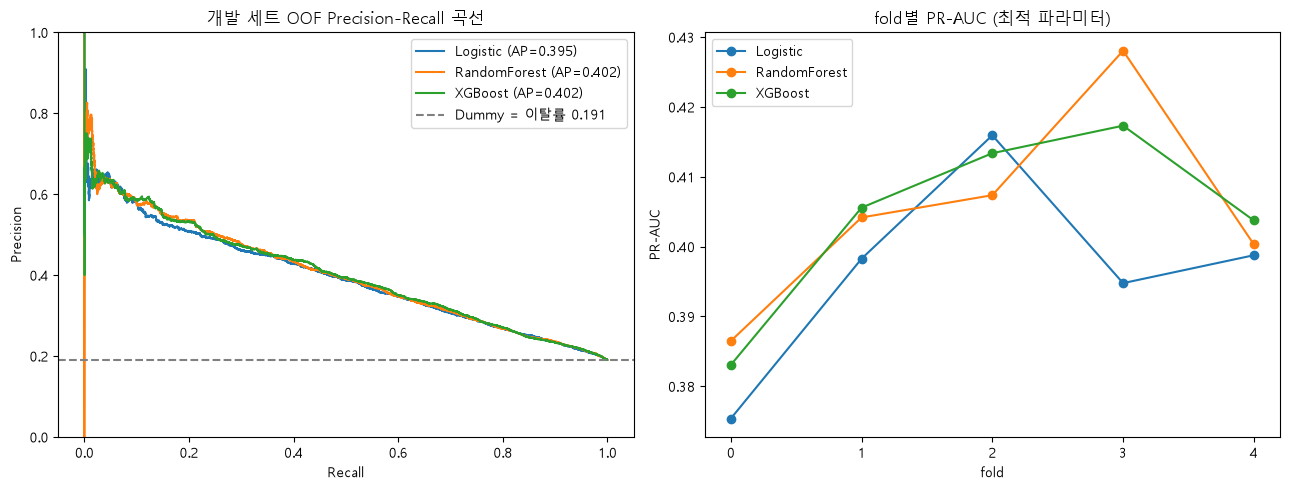

fold별 PR-AUC 순위가 모두 같은 fold 수:
{'Logistic': False, 'RandomForest': False, 'XGBoost': False}


In [10]:
prevalence = y_dev.mean()
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, proba in oof_proba.items():
    if name == 'Dummy':
        continue
    p, r, _ = precision_recall_curve(y_dev, proba)
    axes[0].plot(r, p, label=f'{name} (AP={average_precision_score(y_dev, proba):.3f})')
axes[0].axhline(prevalence, ls='--', c='gray', label=f'Dummy = 이탈률 {prevalence:.3f}')
axes[0].set(xlabel='Recall', ylabel='Precision', title='개발 세트 OOF Precision-Recall 곡선', ylim=(0, 1))
axes[0].legend()

pr_by_fold = pd.DataFrame({
    name: [search.cv_results_[f'split{k}_test_pr_auc'][search.best_index_] for k in range(len(CV_SPLITS))]
    for name, search in search_results.items() if name != 'Dummy'
})
pr_by_fold.index.name = 'fold'
pr_by_fold.plot(marker='o', ax=axes[1])
axes[1].set(xlabel='fold', ylabel='PR-AUC', title='fold별 PR-AUC (최적 파라미터)')
axes[1].set_xticks(range(len(CV_SPLITS)))

plt.tight_layout()
plt.show()

print('fold별 PR-AUC 순위가 모두 같은 fold 수:')
ranks = pr_by_fold.rank(axis=1, ascending=False)
print((ranks.nunique() == 1).to_dict())

## 7. 챔피언 선정과 임계값 선택

### 7.1 챔피언 선정 규칙

사전에 정한 규칙: **CV 평균 PR-AUC가 가장 높은 모델**을 챔피언으로 한다. 단 1위와 2위 차이가
1위의 fold 표준편차보다 작으면 "통계적으로 구분되지 않음"으로 기록한다(선정은 그대로 1위).

In [11]:
ranked = cv_table.sort_values('cv_pr_auc_mean', ascending=False)
CHAMPION = ranked.index[0]
runner_up = ranked.index[1]
gap = ranked.loc[CHAMPION, 'cv_pr_auc_mean'] - ranked.loc[runner_up, 'cv_pr_auc_mean']
champ_std = ranked.loc[CHAMPION, 'cv_pr_auc_std']

# fold별로 짝지어 비교(같은 fold를 쓰므로 쌍대 비교가 가능)
paired_diff = pr_by_fold[CHAMPION] - pr_by_fold[runner_up]

print(f'챔피언: {CHAMPION} (PR-AUC {ranked.loc[CHAMPION, "cv_pr_auc_mean"]:.4f} ± {champ_std:.4f})')
print(f'2위   : {runner_up} (PR-AUC {ranked.loc[runner_up, "cv_pr_auc_mean"]:.4f})')
print(f'차이  : {gap:.4f} / 1위 fold 표준편차 {champ_std:.4f} → '
      f'{"구분 가능" if gap >= champ_std else "통계적으로 구분되지 않음"}')
print(f'fold별 쌍대 차이: {np.round(paired_diff.values, 4)} '
      f'(챔피언이 앞선 fold {int((paired_diff > 0).sum())}/{len(paired_diff)})')
print(f'Dummy 대비 PR-AUC 향상: {ranked.loc[CHAMPION, "cv_pr_auc_mean"] / cv_table.loc["Dummy", "cv_pr_auc_mean"]:.2f}배')

챔피언: RandomForest (PR-AUC 0.4053 ± 0.0134)
2위   : XGBoost (PR-AUC 0.4046)
차이  : 0.0007 / 1위 fold 표준편차 0.0134 → 통계적으로 구분되지 않음
fold별 쌍대 차이: [ 0.0034 -0.0014 -0.006   0.0107 -0.0034] (챔피언이 앞선 fold 2/5)
Dummy 대비 PR-AUC 향상: 2.13배


### 7.2 임계값 선택

실제 개입 비용 수치가 아직 없으므로 **개입 성격에 따른 기준을 여러 개 계산해 두고, 기본값 하나를
잠정 채택**한다. 임계값은 반드시 **개발 세트 OOF 확률로만** 정하고 holdout에는 그 값을 고정해
적용한다(holdout으로 임계값을 고르면 누수).

| 기준 | 의미 | 어울리는 개입 |
|---|---|---|
| **F1 최대 (잠정 기본값)** | Precision·Recall 균형 | 1:1 상담처럼 비용이 중간인 개입 |
| F2 최대 | Recall을 Precision보다 2배 중시 | 알림·안내 메일처럼 저비용 개입 |
| Recall ≥ 0.70 중 Precision 최대 | 이탈자 70% 이상 포착 보장 | 놓치는 비용이 큰 경우 |
| 상위 20% 플래그 | 개입 인력이 정해진 경우 | 튜터 수가 고정된 경우 |

잠정 기본값을 F1로 두는 이유: 이탈률이 약 19%라 F2 최대점은 Recall을 거의 끝까지 끌어올리는
쪽으로 치우쳐 **재학생의 70% 안팎을 위험군으로 표시**한다(아래 표의 `flag_rate`). 그러면 선별
개입이라는 의미가 사라지고 사실상 "전원 알림"과 다르지 않다. 전원 알림이 목적이면 모델이 필요
없으므로, 선별력이 유지되는 F1 최대를 기본으로 두고 실제 개입 수단·인력이 정해지면 표에서 다시
고른다.

In [12]:
champ_proba = oof_proba[CHAMPION]
prec, rec, thr = precision_recall_curve(y_dev, champ_proba)
prec, rec = prec[:-1], rec[:-1]  # 마지막 점(recall=0)은 대응 임계값이 없음

with np.errstate(divide='ignore', invalid='ignore'):
    f1_curve = np.nan_to_num(2 * prec * rec / (prec + rec))
    f2_curve = np.nan_to_num(5 * prec * rec / (4 * prec + rec))

recall_ok = rec >= 0.70
candidates = {
    'F1 최대': thr[np.argmax(f1_curve)],
    'F2 최대': thr[np.argmax(f2_curve)],
    'Recall≥0.70 중 Precision 최대': thr[recall_ok][np.argmax(prec[recall_ok])],
    '상위 20% 플래그': np.quantile(champ_proba, 0.80),
    '기본 0.5': 0.5,
}

threshold_table = pd.DataFrame(
    [{'기준': k, **threshold_metrics(y_dev, champ_proba, v)} for k, v in candidates.items()]
).set_index('기준')
show(threshold_table, {
    'threshold': '{:.4f}', 'precision': '{:.3f}', 'recall': '{:.3f}', 'f1': '{:.3f}',
    'f2': '{:.3f}', 'flag_rate': '{:.1%}',
})

THRESHOLD_RULE = 'F1 최대'
THRESHOLD = float(candidates[THRESHOLD_RULE])
print(f'잠정 채택 임계값: {THRESHOLD_RULE} → {THRESHOLD:.4f}')

,threshold,precision,recall,f1,f2,flag_rate,tp,fp,fn,tn
기준,,,,,,,,,,
F1 최대,0.5250,0.366,0.569,0.446,0.512,29.6%,2007,3477,1519,11501
F2 최대,0.3084,0.239,0.893,0.377,0.577,71.3%,3150,10037,376,4941
Recall≥0.70 중 Precision 최대,0.4344,0.311,0.701,0.430,0.560,43.0%,2470,5482,1056,9496
상위 20% 플래그,0.6177,0.414,0.434,0.424,0.430,20.0%,1532,2169,1994,12809
기본 0.5,0.5000,0.348,0.600,0.441,0.524,32.8%,2115,3961,1411,11017


잠정 채택 임계값: F1 최대 → 0.5250


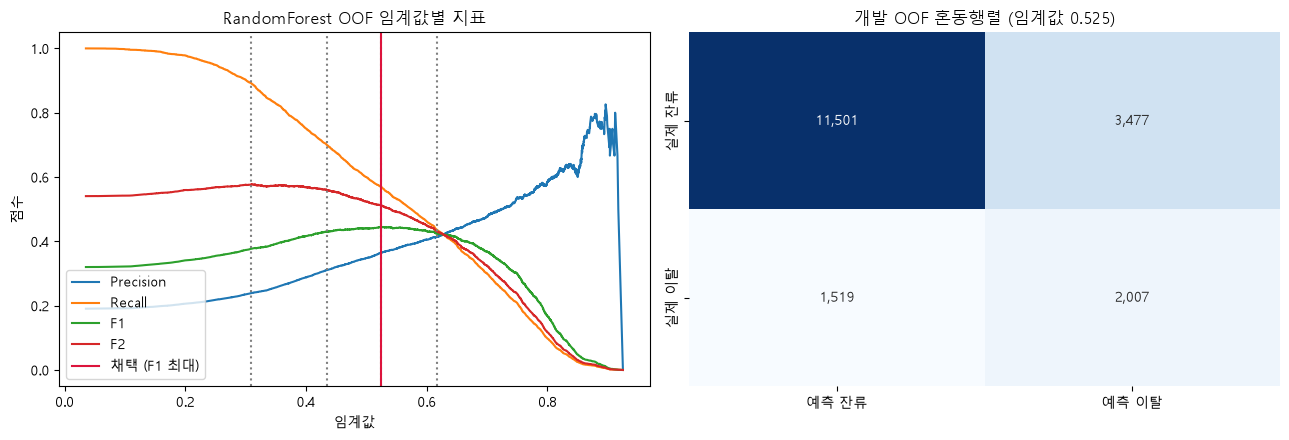

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(thr, prec, label='Precision')
axes[0].plot(thr, rec, label='Recall')
axes[0].plot(thr, f1_curve, label='F1')
axes[0].plot(thr, f2_curve, label='F2')
for label, t in candidates.items():
    if label == '기본 0.5':
        continue
    axes[0].axvline(t, ls=':', c='gray')
axes[0].axvline(THRESHOLD, c='crimson', lw=1.5, label=f'채택 ({THRESHOLD_RULE})')
axes[0].set(xlabel='임계값', ylabel='점수', title=f'{CHAMPION} OOF 임계값별 지표')
axes[0].legend(loc='lower left')

cm = confusion_matrix(y_dev, (champ_proba >= THRESHOLD).astype(int))
sns.heatmap(cm, annot=True, fmt=',', cmap='Blues', cbar=False, ax=axes[1],
            xticklabels=['예측 잔류', '예측 이탈'], yticklabels=['실제 잔류', '실제 이탈'])
axes[1].set_title(f'개발 OOF 혼동행렬 (임계값 {THRESHOLD:.3f})')

plt.tight_layout()
plt.show()

### 7.3 전 모델 공통 임계값 기준 비교

모델마다 확률 스케일이 다르므로 같은 숫자 임계값보다 **같은 기준(F1 최대)** 으로 각자 임계값을
잡았을 때 비교하는 것이 공정하다.

In [14]:
same_rule_rows = []
for name, proba in oof_proba.items():
    if name == 'Dummy':
        continue
    p_, r_, t_ = precision_recall_curve(y_dev, proba)
    p_, r_ = p_[:-1], r_[:-1]
    with np.errstate(divide='ignore', invalid='ignore'):
        f1_ = np.nan_to_num(2 * p_ * r_ / (p_ + r_))
    same_rule_rows.append({'model': name, **threshold_metrics(y_dev, proba, t_[np.argmax(f1_)])})

show(pd.DataFrame(same_rule_rows).set_index('model'), {
    'threshold': '{:.4f}', 'precision': '{:.3f}', 'recall': '{:.3f}', 'f1': '{:.3f}',
    'f2': '{:.3f}', 'flag_rate': '{:.1%}',
})

,threshold,precision,recall,f1,f2,flag_rate,tp,fp,fn,tn
model,,,,,,,,,,
Logistic,0.5217,0.353,0.591,0.442,0.521,31.9%,2084,3826,1442,11152
RandomForest,0.5250,0.366,0.569,0.446,0.512,29.6%,2007,3477,1519,11501
XGBoost,0.5279,0.366,0.581,0.449,0.520,30.3%,2048,3555,1478,11423


## 8. 챔피언 모델 `2014J` holdout 평가

`GridSearchCV(refit=...)`의 `best_estimator_`는 이미 **개발 세트 전체로 재학습**된 상태다.
holdout은 여기서 처음이자 마지막으로 사용한다. 임계값은 7.2절에서 개발 OOF로 정한 값을 그대로
쓴다.

In [15]:
champion_model = search_results[CHAMPION].best_estimator_
hold_proba = champion_model.predict_proba(X_hold)[:, 1]

hold_metrics = {
    'pr_auc': average_precision_score(y_hold, hold_proba),
    'roc_auc': roc_auc_score(y_hold, hold_proba),
    'prevalence': y_hold.mean(),
    **threshold_metrics(y_hold, hold_proba, THRESHOLD),
}

compare = pd.DataFrame({
    '개발 CV(평균)': {
        'pr_auc': cv_table.loc[CHAMPION, 'cv_pr_auc_mean'],
        'roc_auc': cv_table.loc[CHAMPION, 'cv_roc_auc_mean'],
    },
    '개발 OOF': {
        'pr_auc': oof_table.loc[CHAMPION, 'oof_pr_auc'],
        'roc_auc': oof_table.loc[CHAMPION, 'oof_roc_auc'],
        'prevalence': prevalence,
        **{k: v for k, v in threshold_table.loc[THRESHOLD_RULE].items()},
    },
    'holdout 2014J': hold_metrics,
}).loc[['pr_auc', 'roc_auc', 'prevalence', 'threshold', 'precision', 'recall', 'f1', 'f2',
        'flag_rate', 'tp', 'fp', 'fn', 'tn']]
display(compare)

print(f'holdout PR-AUC / 이탈률 = {hold_metrics["pr_auc"] / hold_metrics["prevalence"]:.2f}배 (Dummy 대비 향상)')

,개발 CV(평균),개발 OOF,holdout 2014J
pr_auc,0.405277,0.402071,0.372241
roc_auc,0.726545,0.726125,0.684950
prevalence,NaN,0.190553,0.187978
threshold,NaN,0.524974,0.524974
precision,NaN,0.365974,0.355939
recall,NaN,0.569200,0.491279
f1,NaN,0.445505,0.412799
f2,NaN,0.512303,0.456559
flag_rate,NaN,0.296368,0.259454
tp,NaN,2007.000000,845.000000


holdout PR-AUC / 이탈률 = 1.98배 (Dummy 대비 향상)


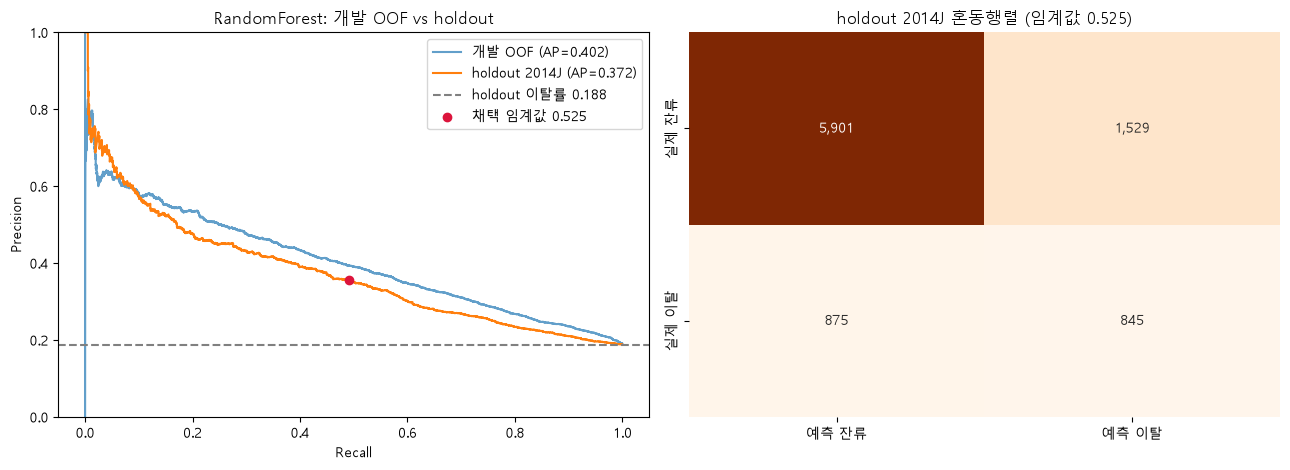

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

p_h, r_h, _ = precision_recall_curve(y_hold, hold_proba)
p_o, r_o, _ = precision_recall_curve(y_dev, champ_proba)
axes[0].plot(r_o, p_o, label=f'개발 OOF (AP={oof_table.loc[CHAMPION, "oof_pr_auc"]:.3f})', alpha=0.7)
axes[0].plot(r_h, p_h, label=f'holdout 2014J (AP={hold_metrics["pr_auc"]:.3f})')
axes[0].axhline(y_hold.mean(), ls='--', c='gray', label=f'holdout 이탈률 {y_hold.mean():.3f}')
axes[0].scatter([hold_metrics['recall']], [hold_metrics['precision']], c='crimson', zorder=5,
                label=f'채택 임계값 {THRESHOLD:.3f}')
axes[0].set(xlabel='Recall', ylabel='Precision', title=f'{CHAMPION}: 개발 OOF vs holdout', ylim=(0, 1))
axes[0].legend()

cm_h = confusion_matrix(y_hold, (hold_proba >= THRESHOLD).astype(int))
sns.heatmap(cm_h, annot=True, fmt=',', cmap='Oranges', cbar=False, ax=axes[1],
            xticklabels=['예측 잔류', '예측 이탈'], yticklabels=['실제 잔류', '실제 이탈'])
axes[1].set_title(f'holdout 2014J 혼동행렬 (임계값 {THRESHOLD:.3f})')

plt.tight_layout()
plt.show()

### 8.1 holdout 모듈별 성능

학기 전체 점수가 괜찮아도 특정 모듈에서 무너질 수 있다. 모듈별 PR-AUC를 이탈률과 함께 본다.

In [17]:
hold_eval = hold_df[['code_module']].assign(y=y_hold.values, proba=hold_proba)
module_rows = []
for module, g in hold_eval.groupby('code_module'):
    row = {'code_module': module, '행 수': len(g), '이탈률': g['y'].mean()}
    if g['y'].nunique() == 2:
        row['pr_auc'] = average_precision_score(g['y'], g['proba'])
        row['roc_auc'] = roc_auc_score(g['y'], g['proba'])
        row['pr_auc/이탈률'] = row['pr_auc'] / row['이탈률']
        m = threshold_metrics(g['y'], g['proba'], THRESHOLD)
        row['recall'] = m['recall']
        row['precision'] = m['precision']
        row['flag_rate'] = m['flag_rate']
    module_rows.append(row)

show(pd.DataFrame(module_rows).set_index('code_module'), {
    '이탈률': '{:.1%}', 'pr_auc': '{:.3f}', 'roc_auc': '{:.3f}', 'pr_auc/이탈률': '{:.2f}',
    'recall': '{:.3f}', 'precision': '{:.3f}', 'flag_rate': '{:.1%}',
})

,행 수,이탈률,pr_auc,roc_auc,pr_auc/이탈률,recall,precision,flag_rate
code_module,,,,,,,,
AAA,348,14.1%,0.233,0.648,1.65,0.429,0.226,26.7%
BBB,1776,13.2%,0.175,0.592,1.33,0.158,0.206,10.1%
CCC,2006,29.2%,0.512,0.707,1.75,0.652,0.455,41.8%
DDD,1450,20.3%,0.377,0.692,1.86,0.650,0.314,42.0%
EEE,1017,13.4%,0.262,0.677,1.96,0.316,0.307,13.8%
FFF,1838,17.9%,0.362,0.703,2.02,0.520,0.333,27.9%
GGG,715,12.9%,0.166,0.585,1.29,0.000,0.000,0.0%


## 9. 결과 저장

재생성 가능한 일반 산출물을 `CSV_files/모델링/`에 저장한다.

- `baseline_cv_comparison_n25.csv`: 모델별 CV·OOF 지표와 최적 파라미터
- `holdout_predictions_n25.csv`: 챔피언의 holdout 예측 확률(그레인 키 포함, 시각화 재사용용)
- `champion_summary_n25.json`: 챔피언·임계값·holdout 지표·환경 정보

마일스톤 스냅샷(`work_process/milestones/`)은 결과 검토와 커밋 후 기준 커밋이 확정되면 만든다.

In [18]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

comparison_out = cv_table.join(oof_table)
comparison_out.to_csv(OUTPUT_DIR / 'baseline_cv_comparison_n25.csv', encoding='utf-8-sig')

hold_pred_out = hold_df[GRAIN].assign(
    **{TARGET: y_hold.values, 'pred_proba': hold_proba,
       'pred_label': (hold_proba >= THRESHOLD).astype(int)}
)
assert not hold_pred_out.duplicated(GRAIN).any()
assert len(hold_pred_out) == len(hold_df)
hold_pred_out.to_csv(OUTPUT_DIR / 'holdout_predictions_n25.csv', index=False, encoding='utf-8-sig')

champion_summary = {
    'created_from': 'Notebooks/03_Modeling/01_Baseline_Models.ipynb',
    'feature_spec': 'CSV_files/통합 버전/feature_spec_n25.json',
    'features_in_order': FEATURES,
    'champion': CHAMPION,
    'best_params': search_results[CHAMPION].best_params_,
    'cv': {
        'splitter': 'StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)',
        'groups': GROUP_COL,
        'dev_terms': sorted(dev_df[HOLDOUT_KEY].unique()),
        'n_dev': len(dev_df),
        'pr_auc_mean': cv_table.loc[CHAMPION, 'cv_pr_auc_mean'],
        'pr_auc_std': cv_table.loc[CHAMPION, 'cv_pr_auc_std'],
    },
    'threshold': {'rule': THRESHOLD_RULE, 'value': THRESHOLD, 'chosen_on': 'dev OOF'},
    'holdout': {'term': HOLDOUT_TERM, 'n': len(hold_df), **hold_metrics},
    'scale_pos_weight': SCALE_POS_WEIGHT,
    'environment': {
        'python': platform.python_version(),
        'pandas': pd.__version__,
        'scikit-learn': sklearn.__version__,
        'xgboost': xgboost.__version__,
    },
}
with open(OUTPUT_DIR / 'champion_summary_n25.json', 'w', encoding='utf-8') as f:
    json.dump(champion_summary, f, ensure_ascii=False, indent=2, default=lambda o: o.item() if hasattr(o, 'item') else str(o))

# 라운드트립 검증
reloaded = pd.read_csv(OUTPUT_DIR / 'holdout_predictions_n25.csv')
assert len(reloaded) == 9150
assert np.allclose(reloaded['pred_proba'].values, hold_proba)
with open(OUTPUT_DIR / 'champion_summary_n25.json', encoding='utf-8') as f:
    assert json.load(f)['champion'] == CHAMPION

for p in sorted(OUTPUT_DIR.iterdir()):
    print(f'{p.relative_to(PROJECT_ROOT)}  ({p.stat().st_size / 1024:.1f} KB)')

CSV_files\모델링\baseline_cv_comparison_n25.csv  (1.5 KB)
CSV_files\모델링\champion_summary_n25.json  (1.8 KB)
CSV_files\모델링\holdout_predictions_n25.csv  (369.8 KB)


## 10. 결론

실행 결과는 위 셀 출력이 정본이다. 요약은 `work_process` 일일 인계에 수치와 함께 기록한다.

남은 판단:

- 임계값 기준 확정 — 현재 **F1 최대**를 잠정 채택. 실제 개입 수단·비용이 정해지면 7.2절 표에서
  다시 선택한다.
- 챔피언이 트리 모델이어도 P5 해석용으로 Logistic을 병행 유지할지 — `region`·`imd_band`
  희소 더미 재검토(열린 이슈)는 Logistic 계수 해석 단계에서 진행한다.
- `date_unregistration` 결측 Withdrawn 93건 민감도 분석은 챔피언 확정 후 별도로 진행한다.